# Pareto sweep analysis

Load a `summary.csv` or `summary.json` from a `pareto_runs/` directory and visualize the Pareto front.

In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point to a completed sweep output directory
RUN_DIR = Path("pareto_runs") / "dale_sanity3_3x3_2026-09-10_12-00-43"

csv_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"

df = pd.read_csv(csv_path)
with json_path.open() as f:
    meta = json.load(f)

print(f"Runs: {len(df)}  |  Pareto points: {df['is_pareto'].sum()}")
print(f"Tasks: {meta['active_tasks']}")
df.head()

Runs: 9  |  Pareto points: 5
Tasks: ['fdgo', 'contextdm1', 'dmsgo']


,run_idx,lambda_rate,lambda_connectivity,task_loss,metabolic_cost,wiring_cost,mean_acc,train_time_s,is_pareto
0,1,0.000,0.000,0.068137,0.477851,0.019683,0.296875,16.408474,False
1,2,0.000,0.005,0.067944,0.533471,0.019159,0.291667,14.894287,False
2,3,0.000,0.010,0.068028,0.493073,0.018748,0.307292,14.805374,False
3,4,0.005,0.000,0.067611,0.303209,0.019708,0.333333,15.635608,True
4,5,0.005,0.005,0.067365,0.334585,0.019120,0.333333,15.482246,True


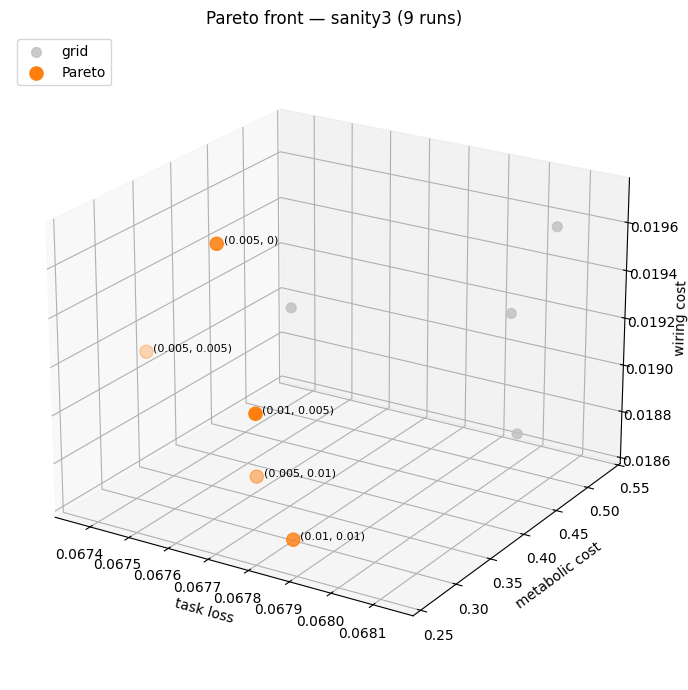

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pareto = df["is_pareto"].astype(bool)
x = df["task_loss"].values
y = df["metabolic_cost"].values
z = df["wiring_cost"].values

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x[~pareto], y[~pareto], z[~pareto], c="0.75", s=50, alpha=0.8, label="grid")
sc = ax.scatter(x[pareto], y[pareto], z[pareto], c="C1", s=90, depthshade=True, label="Pareto")

# Label Pareto points with (lambda_rate, lambda_connectivity)
for _, row in df.loc[pareto].iterrows():
    ax.text(
        row["task_loss"],
        row["metabolic_cost"],
        row["wiring_cost"],
        f"  ({row['lambda_rate']:.3g}, {row['lambda_connectivity']:.3g})",
        fontsize=8,
    )

ax.set_xlabel("task loss")
ax.set_ylabel("metabolic cost")
ax.set_zlabel("wiring cost")
ax.set_title(f"Pareto front — {meta.get('task_battery', '')} ({len(df)} runs)")
ax.legend(loc="upper left")
ax.view_init(elev=22, azim=-58)
fig.tight_layout()
plt.show()

In [7]:
cols = ["lambda_rate", "lambda_connectivity", "task_loss", "metabolic_cost", "wiring_cost", "mean_acc", "is_pareto"]
df.sort_values(["task_loss", "metabolic_cost", "wiring_cost"])[cols]

,lambda_rate,lambda_connectivity,task_loss,metabolic_cost,wiring_cost,mean_acc,is_pareto
4,0.005,0.005,0.067365,0.334585,0.019120,0.333333,True
3,0.005,0.000,0.067611,0.303209,0.019708,0.333333,True
5,0.005,0.010,0.067670,0.321491,0.018743,0.307292,True
7,0.010,0.005,0.067784,0.259616,0.019168,0.317708,True
8,0.010,0.010,0.067846,0.274452,0.018651,0.328125,True
6,0.010,0.000,0.067849,0.272111,0.019593,0.375000,False
1,0.000,0.005,0.067944,0.533471,0.019159,0.291667,False
2,0.000,0.010,0.068028,0.493073,0.018748,0.307292,False
0,0.000,0.000,0.068137,0.477851,0.019683,0.296875,False
